## Historical v1 experiment

This notebook records the earlier 4,000-row methodology. For the current 10,000-row experiment, run `../ml/train_model.py` and consult `../ml/README.md` and `../ml/reports/evaluation_report.json`. Its stored results are not v2 results.


# 01 — Empirical Distribution Analysis for the Synthetic KYC Dataset

**Intelligent Agent Identity Verification System — Module 12**

This notebook documents how the synthetic training data for the SVM KYC classifier was parameterised.
The verification pipeline produces six scores for every agent:

| Feature | Produced by | Scale |
|---|---|---|
| `faceMatchScore` | ArcFace (InsightFace) cosine similarity × 100 | 0 – 100 |
| `livenessScore` | MiniFASNet (Silent-Face) anti-spoofing probability | 0 – 1 |
| `ocrConfidenceScore` | EasyOCR field-matching confidence | 0 – 1 |
| `blurScore` | Variance of the Laplacian | 0 – ∞ (typically < 300) |
| `brightnessScore` | Mean grey-level intensity | 0 – 255 |
| `contrastScore` | Standard deviation of grey-level intensity | 0 – ~128 |

### Why a synthetic dataset?

There is no public dataset of *labelled KYC outcomes* (an agent's six scores paired with a Verified / Manual Review / Rejected decision).
Each individual signal, however, has been studied extensively on academic benchmarks that report how scores behave for genuine
inputs, borderline inputs and attacks. We therefore:

1. Take the score ranges observed for each signal in the literature on its benchmark dataset.
2. Map "genuine / high quality" behaviour to **Verified**, "degraded but not fraudulent" to **Manual Review**, and
   "impostor / attack / unusable" to **Rejected**.
3. Model each class-conditional score as a **clipped normal distribution** $\mathcal{N}(\mu, \sigma^2)$ truncated to $[a, b]$.
4. Sample from those distributions in `ml/generate_dataset.py`.

This notebook does not process the raw benchmark images; it records the agreed parameters and visualises them so the
generator's assumptions are auditable.

## 1. Source benchmark datasets

| Signal | Benchmark | Description | What it informs |
|---|---|---|---|
| Face match | **LFW** — Labeled Faces in the Wild (Huang et al., 2007) | 13,233 web images of 5,749 people; the standard 6,000-pair verification protocol (3,000 genuine, 3,000 impostor pairs) | Separation between genuine-pair and impostor-pair similarity. ArcFace (Deng et al., 2019) reports 99.83 % verification accuracy on LFW, so genuine pairs cluster high and impostors low with a narrow overlap zone. |
| Liveness | **NUAA Photograph Imposter Database** (Tan et al., 2010) | Live faces and printed-photo attacks from 15 subjects captured with webcams | Score behaviour for real faces vs. print attacks under webcam conditions similar to our capture. |
| Liveness | **Replay-Attack** (Chingovska et al., 2012, Idiap) | 1,300 video clips of 50 clients: real access, print and screen-replay attacks under controlled and adverse lighting | Adds replay (screen) attacks and poor-lighting behaviour; motivates a wide *borderline* band. |
| OCR, image quality | **MIDV-500** (Arlazarov et al., 2019) | 500 video clips of 50 identity-document types captured on smartphones under five conditions (table, keyboard, hand, partial, clutter) | OCR confidence and blur / brightness / contrast of document captures ranging from clean to heavily degraded. |

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import truncnorm

%matplotlib inline

# Class colours reused across both notebooks
CLASS_COLOURS = {'verified': '#2a78d6', 'review': '#eb6834', 'rejected': '#1baf7a'}
CLASS_NAMES = {'verified': 'Verified', 'review': 'Manual Review', 'rejected': 'Rejected'}
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True,
                     'grid.alpha': 0.25, 'figure.dpi': 100})

## 2. Agreed class-conditional distributions

Each entry is `(mean, standard deviation, clip low, clip high)`.

### 2.1 Face match score — LFW / ArcFace
Genuine LFW pairs produce ArcFace similarities well above the operating threshold, while impostor pairs sit far below it.
Scores between 50 and 80 correspond to genuine-but-degraded comparisons (pose, ageing between ID photo and selfie, low
resolution of the printed ID portrait) — the cases a human reviewer should inspect.

| Class | μ | σ | Range |
|---|---|---|---|
| Verified | 87.0 | 5.0 | 80 – 100 |
| Manual Review | 65.0 | 8.0 | 50 – 80 |
| Rejected | 35.0 | 10.0 | 0 – 50 |

### 2.2 Liveness score — NUAA and Replay-Attack
Bona fide presentations yield high live-probabilities; print (NUAA) and replay (Replay-Attack) attacks yield low ones.
The Replay-Attack *adverse* lighting subset shows genuine users dropping into a middle band, which motivates the review class.

| Class | μ | σ | Range |
|---|---|---|---|
| Verified | 0.88 | 0.05 | 0.75 – 1.00 |
| Manual Review | 0.62 | 0.08 | 0.50 – 0.75 |
| Rejected | 0.30 | 0.10 | 0.00 – 0.50 |

### 2.3 OCR confidence score — MIDV-500
MIDV-500 "table" captures read cleanly; "hand", "partial" and "clutter" captures lose fields or produce low-confidence reads.

| Class | μ | σ | Range |
|---|---|---|---|
| Verified | 0.82 | 0.06 | 0.70 – 1.00 |
| Manual Review | 0.55 | 0.08 | 0.40 – 0.70 |
| Rejected | 0.25 | 0.10 | 0.00 – 0.40 |

### 2.4 Blur score (Laplacian variance) — MIDV-500 image quality
| Class | μ | σ | Range |
|---|---|---|---|
| Verified | 150.0 | 30.0 | 80 – 300 |
| Manual Review | 65.0 | 12.0 | 40 – 80 |
| Rejected | 30.0 | 10.0 | 0 – 40 |

### 2.5 Brightness score (mean intensity) — MIDV-500 image quality
Manual Review brightness is **bimodal**: most borderline captures are under-exposed (20 – 80), but glare on laminated
documents produces over-exposed captures (above 200). The generator samples 80 % from the under-exposed branch
$\mathcal{N}(55, 15^2)$ on [20, 80] and 20 % from an over-exposed branch $\mathcal{N}(220, 12^2)$ on [200, 255].

| Class | μ | σ | Range |
|---|---|---|---|
| Verified | 140.0 | 25.0 | 80 – 200 |
| Manual Review | 55.0 | 15.0 | 20 – 80, or above 200 |
| Rejected | 20.0 | 8.0 | 0 – 20 |

### 2.6 Contrast score (intensity standard deviation) — MIDV-500 image quality
| Class | μ | σ | Range |
|---|---|---|---|
| Verified | 65.0 | 12.0 | 30 – 100 |
| Manual Review | 22.0 | 5.0 | 15 – 30 |
| Rejected | 10.0 | 4.0 | 0 – 15 |

In [2]:
DISTRIBUTIONS = {
    'verified': {
        'faceMatchScore': (87.0, 5.0, 80.0, 100.0),
        'livenessScore': (0.88, 0.05, 0.75, 1.0),
        'ocrConfidenceScore': (0.82, 0.06, 0.70, 1.0),
        'blurScore': (150.0, 30.0, 80.0, 300.0),
        'brightnessScore': (140.0, 25.0, 80.0, 200.0),
        'contrastScore': (65.0, 12.0, 30.0, 100.0),
    },
    'review': {
        'faceMatchScore': (65.0, 8.0, 50.0, 80.0),
        'livenessScore': (0.62, 0.08, 0.50, 0.75),
        'ocrConfidenceScore': (0.55, 0.08, 0.40, 0.70),
        'blurScore': (65.0, 12.0, 40.0, 80.0),
        'brightnessScore': (55.0, 15.0, 20.0, 80.0),
        'contrastScore': (22.0, 5.0, 15.0, 30.0),
    },
    'rejected': {
        'faceMatchScore': (35.0, 10.0, 0.0, 50.0),
        'livenessScore': (0.30, 0.10, 0.0, 0.50),
        'ocrConfidenceScore': (0.25, 0.10, 0.0, 0.40),
        'blurScore': (30.0, 10.0, 0.0, 40.0),
        'brightnessScore': (20.0, 8.0, 0.0, 20.0),
        'contrastScore': (10.0, 4.0, 0.0, 15.0),
    },
}
REVIEW_OVEREXPOSED_SHARE = 0.20
REVIEW_OVEREXPOSED = (220.0, 12.0, 200.0, 255.0)

FEATURES = list(DISTRIBUTIONS['verified'].keys())
SOURCES = {
    'faceMatchScore': 'LFW / ArcFace',
    'livenessScore': 'NUAA + Replay-Attack',
    'ocrConfidenceScore': 'MIDV-500',
    'blurScore': 'MIDV-500',
    'brightnessScore': 'MIDV-500',
    'contrastScore': 'MIDV-500',
}

rows = []
for cls, feats in DISTRIBUTIONS.items():
    for feat, (mu, sd, lo, hi) in feats.items():
        rows.append({'feature': feat, 'source': SOURCES[feat], 'class': CLASS_NAMES[cls],
                     'mean': mu, 'std': sd, 'clip_low': lo, 'clip_high': hi})
parameter_table = pd.DataFrame(rows).sort_values(['feature', 'mean'], ascending=[True, False])
parameter_table.reset_index(drop=True)

,feature,source,class,mean,std,clip_low,clip_high
0,blurScore,MIDV-500,Verified,150.00,30.00,80.00,300.00
1,blurScore,MIDV-500,Manual Review,65.00,12.00,40.00,80.00
2,blurScore,MIDV-500,Rejected,30.00,10.00,0.00,40.00
3,brightnessScore,MIDV-500,Verified,140.00,25.00,80.00,200.00
4,brightnessScore,MIDV-500,Manual Review,55.00,15.00,20.00,80.00
5,brightnessScore,MIDV-500,Rejected,20.00,8.00,0.00,20.00
6,contrastScore,MIDV-500,Verified,65.00,12.00,30.00,100.00
7,contrastScore,MIDV-500,Manual Review,22.00,5.00,15.00,30.00
8,contrastScore,MIDV-500,Rejected,10.00,4.00,0.00,15.00
9,faceMatchScore,LFW / ArcFace,Verified,87.00,5.00,80.00,100.00


## 3. Visualising the class-conditional densities

Each curve is the probability density of a normal distribution truncated to the clip range
(`scipy.stats.truncnorm`). Clipping with `np.clip` in the generator places the truncated tail mass exactly on the bounds
rather than renormalising it, so the sampled histograms show small spikes at the clip limits; the densities below show the
body of each distribution. Dashed vertical lines mark the clip boundaries between classes (for face, liveness and OCR these coincide with the Module 8 placeholder thresholds).

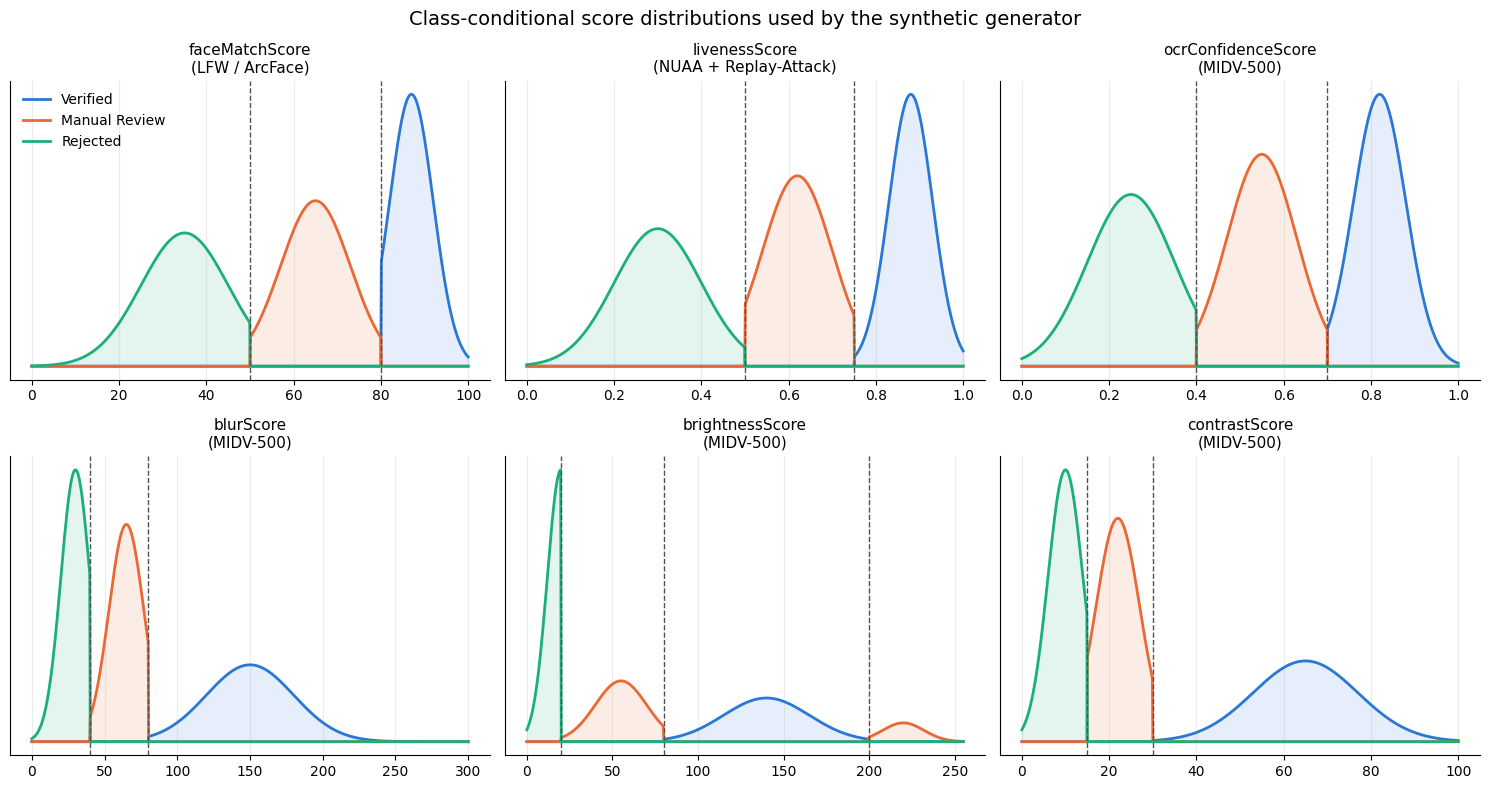

In [3]:
def truncated_pdf(x, mu, sd, lo, hi):
    a, b = (lo - mu) / sd, (hi - mu) / sd
    return truncnorm.pdf(x, a, b, loc=mu, scale=sd)

X_RANGES = {
    'faceMatchScore': (0, 100), 'livenessScore': (0, 1), 'ocrConfidenceScore': (0, 1),
    'blurScore': (0, 300), 'brightnessScore': (0, 255), 'contrastScore': (0, 100),
}
BOUNDARIES = {
    'faceMatchScore': [50, 80], 'livenessScore': [0.5, 0.75], 'ocrConfidenceScore': [0.4, 0.7],
    'blurScore': [40, 80], 'brightnessScore': [20, 80, 200], 'contrastScore': [15, 30],
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flat, FEATURES):
    x = np.linspace(*X_RANGES[feat], 800)
    for cls in ['verified', 'review', 'rejected']:
        mu, sd, lo, hi = DISTRIBUTIONS[cls][feat]
        y = truncated_pdf(x, mu, sd, lo, hi)
        if cls == 'review' and feat == 'brightnessScore':
            y = (1 - REVIEW_OVEREXPOSED_SHARE) * y + REVIEW_OVEREXPOSED_SHARE * truncated_pdf(x, *REVIEW_OVEREXPOSED)
        ax.plot(x, y, color=CLASS_COLOURS[cls], linewidth=2, label=CLASS_NAMES[cls])
        ax.fill_between(x, y, color=CLASS_COLOURS[cls], alpha=0.12)
    for b in BOUNDARIES[feat]:
        ax.axvline(b, color='#52514e', linestyle='--', linewidth=1)
    ax.set_title(f'{feat}\n({SOURCES[feat]})', fontsize=11)
    ax.set_yticks([])
axes.flat[0].legend(frameon=False)
fig.suptitle('Class-conditional score distributions used by the synthetic generator', fontsize=14)
fig.tight_layout()
plt.show()

## 4. Dataset composition and noise

**Class proportions.** 4,000 records: 2,400 Verified (60 %), 800 Manual Review (20 %), 800 Rejected (20 %).
In a production KYC funnel most applicants are genuine, so the majority class is Verified. The imbalance is handled
at training time with `class_weight='balanced'`.

**Noise.** After sampling and clipping, the generator adds zero-mean Gaussian noise to every feature
(σ ≈ 2 % of the feature's natural range: 2.0 face, 0.02 liveness, 0.02 OCR, 5.0 blur, 5.0 brightness, 2.0 contrast)
and clips back to the physical bounds of each score. This softens the otherwise hard edges at the clip limits so the
classifier cannot rely on a perfectly clean boundary.

**Reproducibility.** `random.seed(42)` and `np.random.seed(42)`.

## 5. Consistency check against the generator

The parameters above must match those actually used in `ml/generate_dataset.py`. This cell imports the generator and
asserts the two agree, so the documentation cannot silently drift from the code.

In [4]:
sys.path.insert(0, os.path.abspath(os.path.join('..', 'ml')))
import generate_dataset as gen

assert gen.DISTRIBUTIONS == DISTRIBUTIONS, 'Notebook parameters differ from generate_dataset.py'
assert gen.REVIEW_OVEREXPOSED == REVIEW_OVEREXPOSED
assert gen.REVIEW_OVEREXPOSED_SHARE == REVIEW_OVEREXPOSED_SHARE
assert sum(gen.RECORDS_PER_CLASS.values()) == 4000
print('Generator parameters match this notebook.')
print('Records per class:', gen.RECORDS_PER_CLASS)

Generator parameters match this notebook.
Records per class: {'verified': 2400, 'review': 800, 'rejected': 800}


## 6. Sampled data vs. intended distributions

If the dataset has already been generated, overlay its histograms on the intended densities as a visual sanity check.

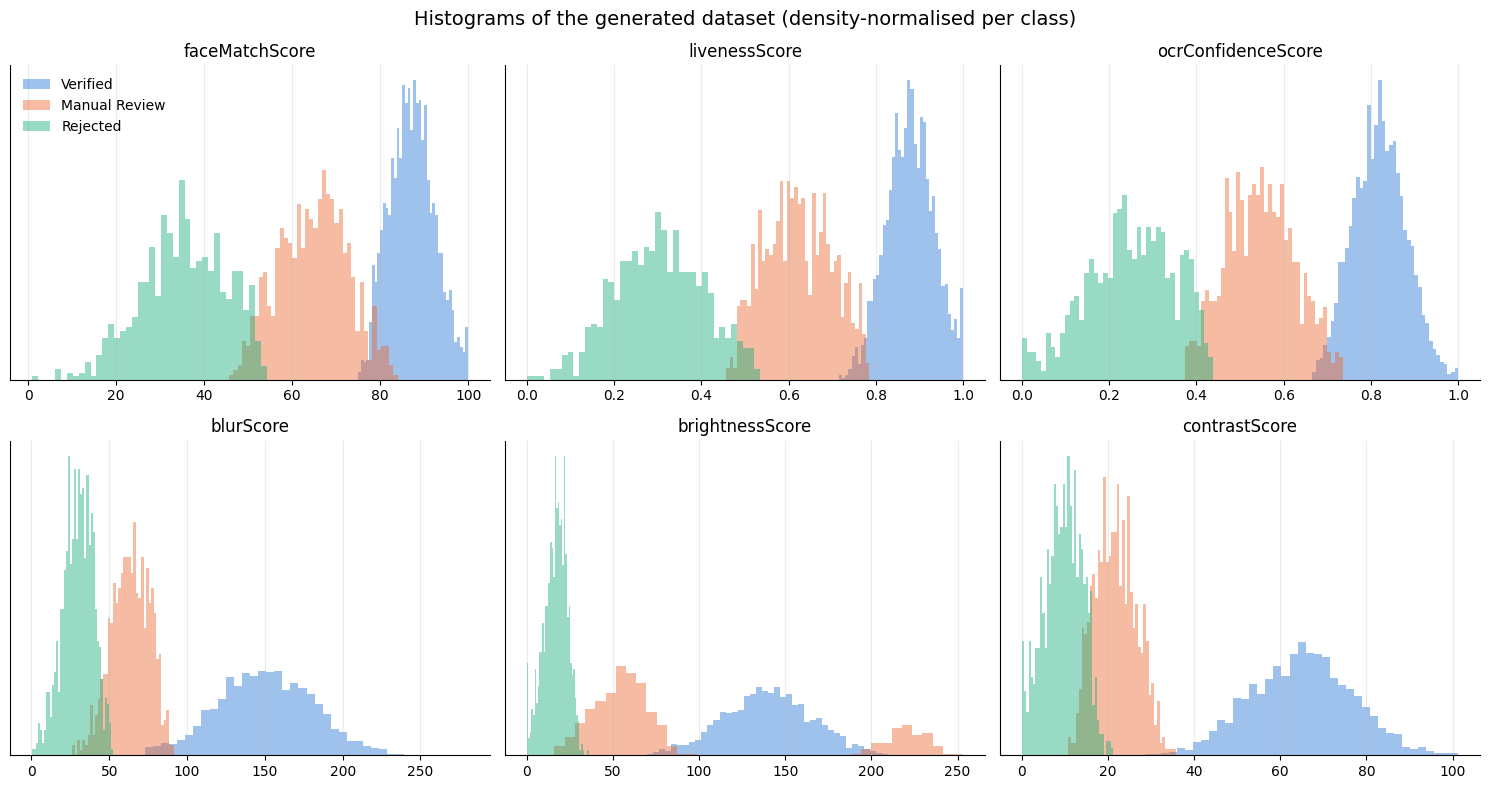

label                          0       1       2
faceMatchScore     mean   87.253  64.774  35.356
                   std     5.026   7.750   9.547
livenessScore      mean    0.878   0.622   0.302
                   std     0.054   0.076   0.101
ocrConfidenceScore mean    0.820   0.547   0.249
                   std     0.060   0.078   0.099
blurScore          mean  150.568  63.673  29.759
                   std    30.274  12.184   9.644
brightnessScore    mean  139.936  88.747  16.763
                   std    25.313  69.097   6.693
contrastScore      mean   65.052  21.764   9.655
                   std    11.713   4.757   4.365


In [5]:
DATA_PATH = os.path.join('..', 'ml', 'data', 'synthetic_verification_dataset.csv')
LABEL_TO_CLASS = {0: 'verified', 1: 'review', 2: 'rejected'}

if os.path.exists(DATA_PATH):
    data = pd.read_csv(DATA_PATH)
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for ax, feat in zip(axes.flat, FEATURES):
        for label, cls in LABEL_TO_CLASS.items():
            ax.hist(data.loc[data['label'] == label, feat], bins=40, density=True,
                    color=CLASS_COLOURS[cls], alpha=0.45, label=CLASS_NAMES[cls])
        ax.set_title(feat)
        ax.set_yticks([])
    axes.flat[0].legend(frameon=False)
    fig.suptitle('Histograms of the generated dataset (density-normalised per class)', fontsize=14)
    fig.tight_layout()
    plt.show()
    print(data.groupby('label')[FEATURES].agg(['mean', 'std']).round(3).T)
else:
    print('Dataset not generated yet — run `python ml/generate_dataset.py` from ai-service/.')

## 7. Empirical validation — scores measured by this system on the benchmarks

The parameters above come from the literature. To check them, `ml/measure_benchmarks.py` ran this project's own
services on samples of the benchmark datasets and saved one row per sample to `ml/data/benchmarks/`:

| File | Service | Sample |
|---|---|---|
| `lfw_face_match.csv` | `faceMatchService` (ArcFace) | LFW DevTest: 500 genuine + 500 impostor pairs |
| `nuaa_liveness.csv` | `livenessService` (MiniFASNet) | NUAA test split: 600 real-face + 600 photo-attack images (random, seed 42) |
| `midv_image_quality.csv` | `imageQualityService` (document mode) | MIDV-500: 50 documents × 10 capture conditions, 1 frame each |
| `midv_ocr.csv` | EasyOCR reader from `ocrService` | Same frames; each Latin-script ground-truth field is cropped after warping the frame to the document template, read, and scored by normalised Levenshtein similarity to the true value (averaged per frame) |

The OCR measurement is a **proxy**: production `ocrConfidenceScore` is a Kenyan-ID field-matching score
(name coverage, ID-number match, DOB match), which cannot be computed on MIDV-500's foreign documents. The proxy keeps
the same idea — how well the extracted fields match the expected values — using MIDV-500's ground truth.

Only the CSVs are needed to run this section; the raw datasets are not.

In [6]:
BENCH_DIR = os.path.join('..', 'ml', 'data', 'benchmarks')

def load_bench(name):
    path = os.path.join(BENCH_DIR, name)
    return pd.read_csv(path) if os.path.exists(path) else None

lfw = load_bench('lfw_face_match.csv')
nuaa = load_bench('nuaa_liveness.csv')
midv_q = load_bench('midv_image_quality.csv')
midv_o = load_bench('midv_ocr.csv')
print({name: (None if df is None else len(df)) for name, df in
       [('lfw', lfw), ('nuaa', nuaa), ('midv_quality', midv_q), ('midv_ocr', midv_o)]})

{'lfw': 1000, 'nuaa': 1200, 'midv_quality': 500, 'midv_ocr': 480}


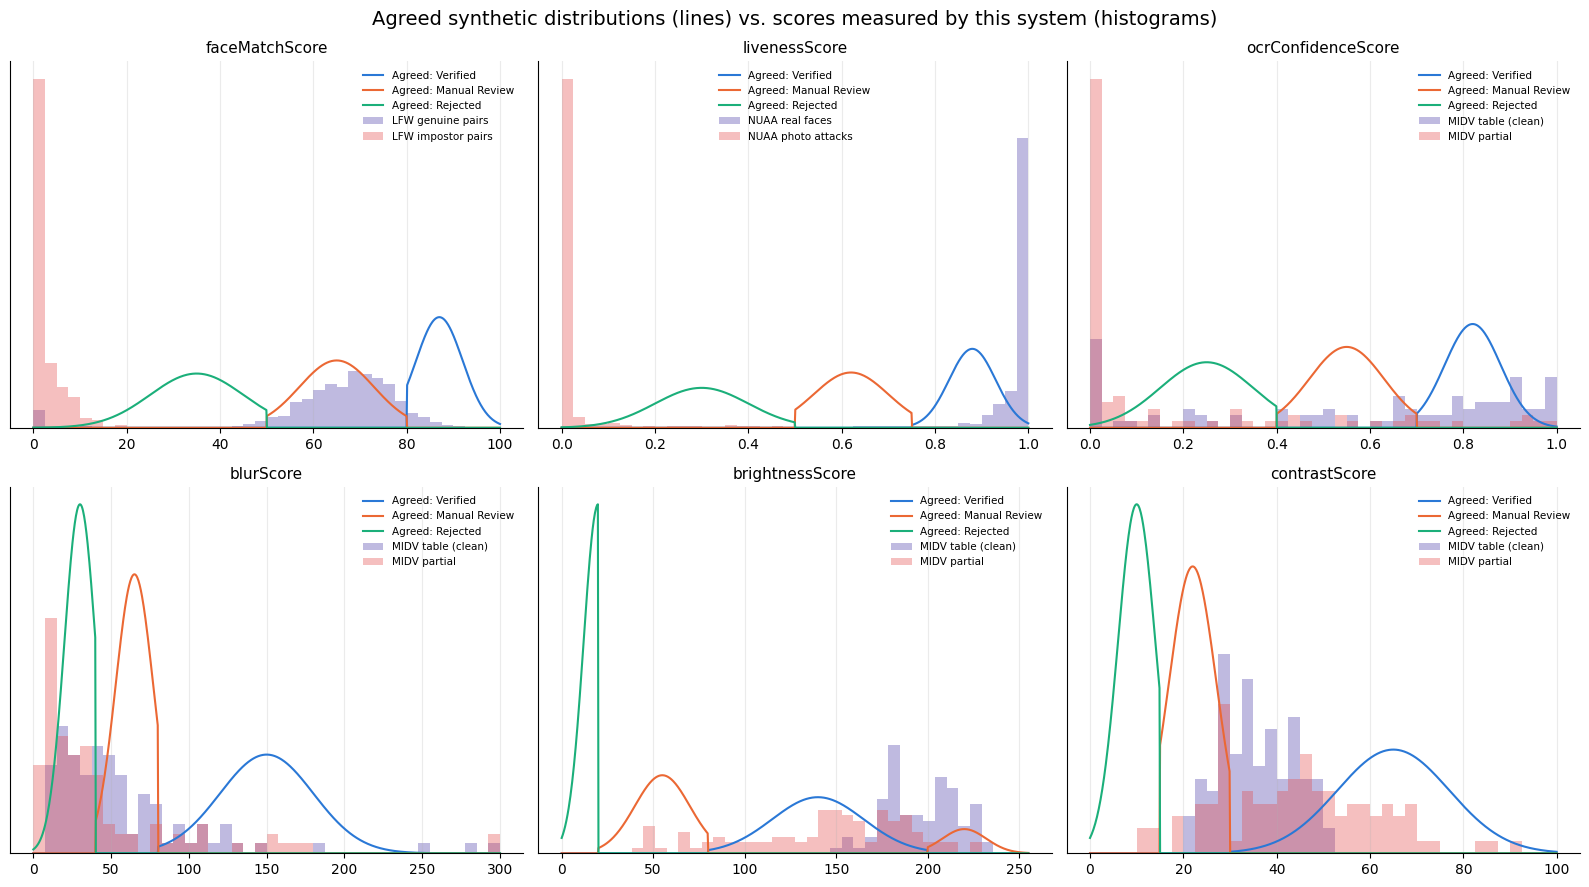

In [7]:
# Measured scores (histograms) against the agreed class densities (lines).
# Measured groups: LFW genuine/impostor pairs, NUAA real/attack images,
# MIDV-500 'table' captures (clean) vs 'partial' captures (document partly out of frame).
MEASURED = {
    'faceMatchScore': (lfw, 'pair_type', {'genuine': 'LFW genuine pairs', 'impostor': 'LFW impostor pairs'}),
    'livenessScore': (nuaa, 'presentation', {'real': 'NUAA real faces', 'photo_attack': 'NUAA photo attacks'}),
    'ocrConfidenceScore': (midv_o, 'setting', {'table': 'MIDV table (clean)', 'partial': 'MIDV partial'}),
    'blurScore': (midv_q, 'setting', {'table': 'MIDV table (clean)', 'partial': 'MIDV partial'}),
    'brightnessScore': (midv_q, 'setting', {'table': 'MIDV table (clean)', 'partial': 'MIDV partial'}),
    'contrastScore': (midv_q, 'setting', {'table': 'MIDV table (clean)', 'partial': 'MIDV partial'}),
}
MEASURED_COLOURS = ['#4a3aa7', '#e34948']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, feat in zip(axes.flat, FEATURES):
    lo, hi = X_RANGES[feat]
    x = np.linspace(lo, hi, 800)
    for cls in ['verified', 'review', 'rejected']:
        mu, sd, a, b = DISTRIBUTIONS[cls][feat]
        y = truncated_pdf(x, mu, sd, a, b)
        if cls == 'review' and feat == 'brightnessScore':
            y = (1 - REVIEW_OVEREXPOSED_SHARE) * y + REVIEW_OVEREXPOSED_SHARE * truncated_pdf(x, *REVIEW_OVEREXPOSED)
        ax.plot(x, y, color=CLASS_COLOURS[cls], linewidth=1.5, label=f'Agreed: {CLASS_NAMES[cls]}')
    frame, column, groups = MEASURED[feat]
    if frame is not None:
        for colour, (key, label) in zip(MEASURED_COLOURS, groups.items()):
            values = frame.loc[frame[column] == key, feat].clip(lo, hi)
            ax.hist(values, bins=40, range=(lo, hi), density=True, color=colour, alpha=0.35, label=label)
    ax.set_title(feat, fontsize=11)
    ax.set_yticks([])
    ax.legend(frameon=False, fontsize=7.5)
fig.suptitle('Agreed synthetic distributions (lines) vs. scores measured by this system (histograms)', fontsize=14)
fig.tight_layout()
plt.show()

In [8]:
def pct_in(values, lo, hi):
    values = pd.Series(values).dropna()
    return round(100 * ((values >= lo) & (values <= hi)).mean(), 1)

rows = []
def add(feature, group, values):
    v = pd.Series(values).dropna()
    vlo, vhi = DISTRIBUTIONS['verified'][feature][2:]
    rlo, rhi = DISTRIBUTIONS['rejected'][feature][2:]
    rows.append({'feature': feature, 'measured group': group, 'n': len(v),
                 'median': round(v.median(), 3), 'p05': round(v.quantile(.05), 3), 'p95': round(v.quantile(.95), 3),
                 'agreed Verified mean': DISTRIBUTIONS['verified'][feature][0],
                 '% in Verified range': pct_in(v, vlo, vhi), '% in Rejected range': pct_in(v, rlo, rhi)})

if lfw is not None:
    for key, label in [('genuine', 'LFW genuine'), ('impostor', 'LFW impostor')]:
        add('faceMatchScore', label, lfw.loc[lfw.pair_type == key, 'faceMatchScore'])
if nuaa is not None:
    for key, label in [('real', 'NUAA real'), ('photo_attack', 'NUAA photo attack')]:
        add('livenessScore', label, nuaa.loc[nuaa.presentation == key, 'livenessScore'])
if midv_o is not None:
    for setting in ['table', 'keyboard', 'hand', 'clutter', 'partial']:
        add('ocrConfidenceScore', f'MIDV {setting}', midv_o.loc[midv_o.setting == setting, 'ocrConfidenceScore'])
if midv_q is not None:
    for feat in ['blurScore', 'brightnessScore', 'contrastScore']:
        for setting in ['table', 'hand', 'partial']:
            add(feat, f'MIDV {setting}', midv_q.loc[midv_q.setting == setting, feat])

comparison = pd.DataFrame(rows)
comparison

,feature,measured group,n,median,p05,p95,agreed Verified mean,% in Verified range,% in Rejected range
0,faceMatchScore,LFW genuine,500,68.287,36.997,81.922,87.00,7.4,8.0
1,faceMatchScore,LFW impostor,500,0.000,0.000,9.488,87.00,0.0,100.0
2,livenessScore,NUAA real,600,0.994,0.852,1.000,0.88,97.0,0.5
3,livenessScore,NUAA photo attack,600,0.000,0.000,0.113,0.88,0.0,99.5
4,ocrConfidenceScore,MIDV table,96,0.697,0.000,0.986,0.82,50.0,27.1
5,ocrConfidenceScore,MIDV keyboard,96,0.510,0.000,0.948,0.82,31.2,41.7
6,ocrConfidenceScore,MIDV hand,96,0.650,0.000,0.975,0.82,43.8,28.1
7,ocrConfidenceScore,MIDV clutter,96,0.461,0.000,0.954,0.82,29.2,44.8
8,ocrConfidenceScore,MIDV partial,96,0.000,0.000,0.824,0.82,8.3,80.2
9,blurScore,MIDV table,100,44.398,10.798,130.130,150.00,21.0,44.0


### 7.1 Findings

**Liveness — agreed thresholds confirmed.** On NUAA, 97 % of real faces score at or above 0.75 (the Verified boundary)
and no photo attack does; 99.5 % of real faces clear 0.50. The measured distributions are more extreme than the agreed
ones (real faces median ≈ 0.99, attacks median ≈ 0.00): the deployed MiniFASNet model separates the classes more
sharply than the literature-based parameters assume, but the thresholds themselves are supported.

**Face match — the Verified range is too high for this model.** ArcFace separates LFW identities almost perfectly
(no impostor pair scores above ≈ 19; 95 % of genuine pairs score above ≈ 37), but genuine pairs have a median of
≈ 68 and only ≈ 7 % reach 80. The agreed Verified distribution (μ = 87, range 80–100) describes a similarity level
this model rarely produces, and the agreed Rejected range (0–50) overlaps a meaningful share of genuine pairs.
Production compares an ID-card portrait with a live selfie, which is harder than LFW photo-to-photo matching, so real
genuine scores are likely to be lower still.

**Blur — the Verified range is too high for MIDV-500 captures.** Even clean "table" captures have a median Laplacian
variance well below 80. Part of this is dataset-specific (compressed smartphone video frames of glossy documents), so
the gap may be smaller for still photos from the capture wizard, but the agreed 80–300 range is not supported here.

**Brightness — clean documents sit at the top of, and often above, the Verified range.** White document backgrounds
under good lighting give brightness near 200, and a large share of clean captures exceed 200 — which the agreed
parameters assign to the over-exposed Manual Review branch.

**Contrast — broadly consistent**, with real documents mostly in the lower part of the Verified range.

**OCR (proxy) — clean captures sit around the Verified / Review boundary** (median ≈ 0.70) with a wide spread, and
partial captures mostly fail. As a proxy on foreign documents this supports only a coarse conclusion: 0.82 is an
optimistic centre for Verified.

**Implication.** The deployed models are strongly discriminative, but for face match, blur and brightness the agreed
Verified ranges sit above the scores these models actually produce on genuine inputs. A classifier trained on the
agreed distributions will be conservative, routing genuine applicants to Manual Review more often than the synthetic
test metrics suggest. Re-parameterising the generator from these measurements, and ultimately retraining on the
system's own admin-labelled decisions, are the natural next steps.

## 8. Limitations

* **Separable by construction.** The agreed clip ranges for the three classes do not overlap on any feature, so each
  signal on its own nearly separates the classes. The injected noise creates only a thin overlap band. Near-perfect
  classifier accuracy on this dataset therefore reflects how the data was built, not how the model will perform on real
  applicants.
* **Independent features.** Features are sampled independently within each class. In reality they are correlated
  (a blurry capture lowers both OCR confidence and face-match similarity), and a real borderline applicant usually has
  one or two weak signals rather than all six in the review band.
* **Literature-derived parameters.** The generator's parameters summarise published behaviour on the benchmarks.
  Section 7 measures this system's own models on the benchmarks and finds that the face-match, blur and brightness
  Verified ranges sit above the measured genuine scores; the generator has not (yet) been refitted to those measurements.